In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
from pyspark.sql.functions import *
from pyspark.sql.types import *

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df_data = spark.read.format("json").option("schema","True").load("/content/drive/MyDrive/data - MoMD/Office_Products.jsonl")

In [ ]:
meta_schema = StructType([
    StructField("main_category", StringType(), True),
    StructField("title", StringType(), True),
    StructField("average_rating", DoubleType(), True),
    StructField("rating_number", LongType(), True),
    StructField("features", ArrayType(StringType()), True),
    StructField("description", ArrayType(StringType()), True),
    StructField("price", DoubleType(), True),
    StructField("images", ArrayType(MapType(StringType(), StringType())), True),
    StructField("videos", ArrayType(MapType(StringType(), StringType())), True),
    StructField("store", StringType(), True),
    StructField("categories", ArrayType(StringType()), True),

    StructField("details", StringType(), True),

    StructField("parent_asin", StringType(), True),
    StructField("bought_together", DoubleType(), True),
    StructField("subtitle", StringType(), True),
    StructField("author", StringType(), True),
])
raw_meta_df = spark.read.text("/content/drive/MyDrive/data - MoMD/meta_Office_Products.jsonl")
meta_df = (
    raw_meta_df
    .select(from_json(col("value"), meta_schema).alias("data"))
    .select("data.*")
)

In [ ]:
df_data.show()

+----------+------------+--------------------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|      asin|helpful_vote|              images|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase|
+----------+------------+--------------------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|B01AHHL4X2|           0|                  []| B01MZ3SD2X|   5.0|Lovely ink. Write...|1677939345945| Pretty & I love it!|AFKZENTNBQ7A7V7UX...|             true|
|B08L6H23JZ|           0|                  []| B08L6H23JZ|   4.0|Overall I’m prett...|1677939160682|2 excellent 1 ext...|AFKZENTNBQ7A7V7UX...|             true|
|B07JDZ5J46|           2|                  []| B07JDZ5J46|   1.0|[[VIDEOID:63276c1...|1660188831933|I don’t get the r...|AFKZENTNBQ7A7V7UX...|             true|
|B004MNX7EW|           0|[{IMAGE, 

## **Rating statistic**

In [ ]:
df_data.groupBy("rating").count().show()

+------+-------+
|rating|  count|
+------+-------+
|   1.0|1353519|
|   4.0|1400675|
|   3.0| 799194|
|   2.0| 589120|
|   5.0|8703203|
|   0.0|      1|
+------+-------+



In [4]:
product_rating = df_data.groupBy("asin").agg(count("rating").alias("count")).sort(desc("count"))
product_rating.show()

+----------+-----+
|      asin|count|
+----------+-----+
|B01EBDV9BU|17538|
|B00YFTHJ9C|14522|
|B00HFJWKWK|13062|
|B01G643EU6|12129|
|B00AVWKUJS|11768|
|B0028SCBV8|11150|
|B010TLSFA6| 8911|
|B0772XSNXY| 8540|
|B01CTIG4GE| 8110|
|B00SMHWZ42| 8030|
|B005QAQFFS| 7862|
|B003YT6RNS| 7301|
|B013SKI4EM| 7143|
|B000J07BRQ| 6983|
|B00006IEI4| 6840|
|B00BUI5QWS| 6654|
|B003H2GBM4| 6449|
|B0010JEJPC| 6361|
|B009QYH644| 6340|
|B0147WIC7E| 6302|
+----------+-----+
only showing top 20 rows


In [7]:
product_rating.select("asin").distinct().count()

906049

In [8]:
rdd_product = product_rating.select("count").rdd.map(lambda x: x[0])

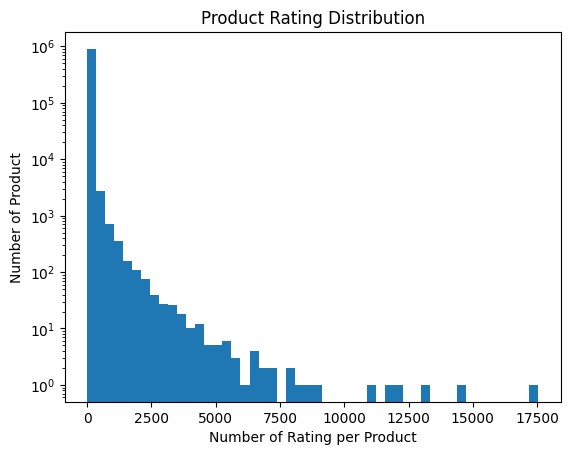

In [20]:
plt.hist(rdd_product.collect(), bins=50)
plt.yscale("log")

plt.xlabel("Number of Rating per Product")
plt.ylabel("Number of Product")
plt.title("Product Rating Distribution")
plt.show()

In [17]:
user_rating = df_data.groupBy("user_id").agg(count("rating").alias("count")).sort(desc("count"))
user_rating.show()

+--------------------+-----+
|             user_id|count|
+--------------------+-----+
|AG375WAXLZ7PIOQKI...|  921|
|AGZZXSMMS4WRHHJRB...|  733|
|AEIIRIHLIYKQGI7ZO...|  606|
|AH665SQ6SQF6DXAGY...|  522|
|AHV6QCNBJNSGLATP5...|  457|
|AGLW3CD3PK4YA4HA7...|  450|
|AGF3GTGWVWB7QONIO...|  316|
|AGSP6LSQK32SQEJO3...|  295|
|AE64UFB76MUZT2F2V...|  266|
|AF4P6A3SEKS2HCISW...|  263|
|AFMTMYG7S76LUVRJQ...|  261|
|AG73BVBKUOH22USSF...|  259|
|AF3ODW6NCKEVVTGZN...|  258|
|AED3PQGKE2MP7OA6Y...|  250|
|AGBG3KK74IKWJNQVM...|  244|
|AH5HSMUMRJRDWBPFD...|  239|
|AGEDJFJ6BQJEJ3DQO...|  234|
|AFTZWAK3ZHAPCNSOT...|  228|
|AG5LC5HSFYGJSK3AQ...|  214|
|AFZUK3MTBIBEDQOPA...|  213|
+--------------------+-----+
only showing top 20 rows


In [18]:
rrd_user = user_rating.select("count").rdd.map(lambda x: x[0])

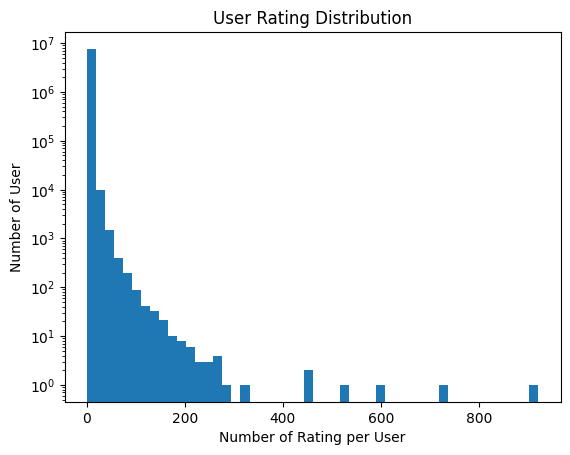

In [19]:
plt.hist(rrd_user.collect(), bins=50)
plt.yscale("log")

plt.xlabel("Number of Rating per User")
plt.ylabel("Number of User")
plt.title("User Rating Distribution")
plt.show()

In [29]:
top_product = product_rating.limit(20000).toPandas()

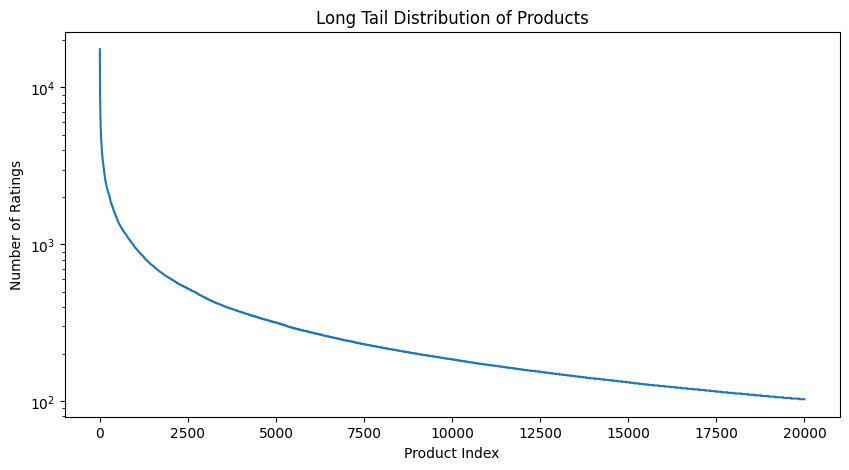

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(top_product['count'].values)

plt.yscale("log")

plt.xlabel('Product Index')
plt.ylabel('Number of Ratings')
plt.title('Long Tail Distribution of Products')
plt.show()

Max product rating count and min product rating count



In [ ]:
product_rating.agg(
    min("count").alias("min_rating_count"),
    max("count").alias("max_rating_count")
).show()

+----------------+----------------+
|min_rating_count|max_rating_count|
+----------------+----------------+
|               1|           17538|
+----------------+----------------+



Max user rating count and min user rating count

In [ ]:
user_rating.agg(
    min("count").alias("min_rating_count"),
    max("count").alias("max_rating_count")
).show()

+----------------+----------------+
|min_rating_count|max_rating_count|
+----------------+----------------+
|               1|             921|
+----------------+----------------+



# Data Time

In [38]:
from pyspark.sql.functions import col, from_unixtime, year

df_time = df_data.select("timestamp").withColumn("datetime", from_unixtime(col("timestamp")/1000))
time_range = df_time.agg(
    min("datetime").alias("min_datetime"),
    max("datetime").alias("max_datetime")
)

In [39]:
time_range.show(truncate = False)

+-------------------+-------------------+
|min_datetime       |max_datetime       |
+-------------------+-------------------+
|1998-10-12 04:07:40|2023-09-12 20:49:01|
+-------------------+-------------------+



In [40]:
df_time = df_time.join(
    df_data.select("rating","timestamp"),
    on="timestamp",
    how="right"
)

In [ ]:
df_time = df_time.withColumn("year", year("datetime")).groupBy("year").count().orderBy("year").toPandas()

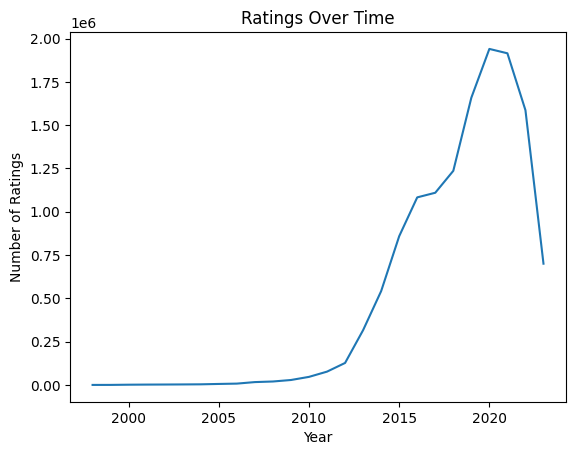

In [48]:
plt.plot(df_time["year"], df_time["count"])

plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.title("Ratings Over Time")
plt.show()